In [9]:
#!pip install optuna

In [10]:
# 1. Importaciones
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, f1_score, balanced_accuracy_score
from sklearn.datasets import make_moons, make_circles, load_breast_cancer
from sklearn.datasets import fetch_openml
from sklearn.preprocessing import LabelEncoder
import optuna
import warnings

from sklearn.base import clone
from copy import deepcopy
from sklearn.model_selection import StratifiedKFold
import time

from scipy.stats import f_oneway
import matplotlib.pyplot as plt

import seaborn as sns
import gc
import tracemalloc
from joblib import Parallel, delayed


warnings.filterwarnings('ignore')

In [11]:
def encode_target(y):
    if isinstance(y[0], str):
        y = LabelEncoder().fit_transform(y)
    return y.astype(int)

# 2. Cargar Datasets adecuados
def load_datasets():
    datasets = []

    from sklearn.datasets import fetch_openml
    from sklearn.datasets import load_breast_cancer

    # Dataset: Banknote Authentication (Seguridad bancaria)
    X, y = fetch_openml(name="banknote-authentication", version=1, return_X_y=True, as_frame=False)
    datasets.append(("BanknoteAuth", X, y.astype(int)))

    # Dataset: Breast Cancer (WDBC)
    data = load_breast_cancer()
    datasets.append(("BreastCancer", data.data, data.target))

    # Dataset: Heart Disease Cleveland (UCI)
    X, y = fetch_openml(data_id=53, return_X_y=True, as_frame=True)
    X = X.select_dtypes(include='number').to_numpy()
    y = encode_target(y)
    datasets.append(("HeartDisease", X, y))

    
    # Dataset: Ionosphere (Radar UCI)
    X_df, y = fetch_openml(name="ionosphere", version=1, return_X_y=True, as_frame=True)
    y = encode_target(y)
    datasets.append(("Ionosphere", X_df.values.astype(float), y))

    # Dataset: KC2 Software Defect Prediction
    X, y = fetch_openml(name="kc2", version=1, return_X_y=True, as_frame=False)
    datasets.append(("KC2", X, y))

    # Dataset: QSAR Biodegradation (Biodegradabilidad química)
    X, y = fetch_openml(name="QSAR-Biodeg", version=1, return_X_y=True, as_frame=False)
    datasets.append(("QSARBiodeg", X, y.astype(int)))

    # Dataset: SpamBase (UCI)
    X, y = fetch_openml(name="spambase", version=1, return_X_y=True, as_frame=False)
    datasets.append(("SpamBase", X, y.astype(int)))
     

    return datasets

In [12]:
# 3. Definir funciones de entrenamiento para los métodos

def train_base(X_train, y_train, X_val=None, y_val=None):
    t_start = time.perf_counter()
    clf = DecisionTreeClassifier(random_state=42)
    clf.fit(X_train, y_train)
    train_time_ms = (time.perf_counter() - t_start) * 1000
    return clf, train_time_ms, 0.0

def train_ccp(X_train, y_train, X_val, y_val):
    t_start = time.perf_counter()
    path = DecisionTreeClassifier(random_state=42).cost_complexity_pruning_path(X_train, y_train)
    ccp_alphas = path.ccp_alphas
    best_score = 0
    best_alpha = 0
    for alpha in ccp_alphas:
        clf = DecisionTreeClassifier(random_state=42, ccp_alpha=alpha)
        clf.fit(X_train, y_train)
        score = accuracy_score(y_val, clf.predict(X_val))
        if score > best_score:
            best_score = score
            best_alpha = alpha
    train_time_ms = (time.perf_counter() - t_start) * 1000
    t_prune = time.perf_counter()
    final_model = DecisionTreeClassifier(random_state=42, ccp_alpha=best_alpha)
    final_model.fit(X_train, y_train)
    prune_time_ms = (time.perf_counter() - t_prune) * 1000
    return final_model, train_time_ms, prune_time_ms

def train_ccp_modified_optimized(X_train, y_train, X_val, y_val, seed=42, n_trials=60):
    path = DecisionTreeClassifier(random_state=seed).cost_complexity_pruning_path(X_train, y_train)
    ccp_alphas = path.ccp_alphas
    n_total_features = X_train.shape[1]

    cached_trees = []
    for alpha in ccp_alphas:
        t = DecisionTreeClassifier(random_state=seed, ccp_alpha=alpha).fit(X_train, y_train)
        cached_trees.append({
            "alpha": alpha,
            "acc_train": accuracy_score(y_train, t.predict(X_train)),
            "acc_val": accuracy_score(y_val, t.predict(X_val)),
            "depth": t.get_depth(),
            "n_used": count_used_features(t),
        })

    def compute_modified_alpha(c, depth_penalty, feature_penalty_weight):
        return (c["alpha"] * (1 + abs(c["acc_train"] - c["acc_val"]))
                + depth_penalty * c["depth"]
                + feature_penalty_weight * (c["n_used"] / n_total_features))

    def eval_alpha(c, depth_penalty, feature_penalty_weight):
        modified_alpha = compute_modified_alpha(c, depth_penalty, feature_penalty_weight)
        clf = DecisionTreeClassifier(random_state=seed, ccp_alpha=modified_alpha).fit(X_train, y_train)
        return accuracy_score(y_val, clf.predict(X_val))

    def objective(trial):
        depth_penalty = trial.suggest_float("depth_penalty", 0.0001, 0.01)
        feature_penalty_weight = trial.suggest_float("feature_penalty_weight", 0.01, 0.2)
        scores = Parallel(n_jobs=1)(
            delayed(eval_alpha)(c, depth_penalty, feature_penalty_weight)
            for c in cached_trees
        )
        return max(scores)

    t_start = time.perf_counter()
    sampler = optuna.samplers.TPESampler(seed=seed)
    study = optuna.create_study(direction="maximize", sampler=sampler)
    study.optimize(objective, n_trials=n_trials, timeout=1000, n_jobs=4)
    best_params = study.best_params
    depth_penalty = best_params["depth_penalty"]
    feature_penalty_weight = best_params["feature_penalty_weight"]
    train_time_ms = (time.perf_counter() - t_start) * 1000

    t_prune = time.perf_counter()
    scores = Parallel(n_jobs=1)(
        delayed(eval_alpha)(c, depth_penalty, feature_penalty_weight)
        for c in cached_trees
    )
    best_idx = int(np.argmax(scores))
    best_c = cached_trees[best_idx]
    best_modified_alpha = compute_modified_alpha(best_c, depth_penalty, feature_penalty_weight)
    best_model = DecisionTreeClassifier(random_state=seed, ccp_alpha=best_modified_alpha).fit(X_train, y_train)
    prune_time_ms = (time.perf_counter() - t_prune) * 1000

    return best_model, train_time_ms, prune_time_ms

def train_rep(X_train, y_train, X_val, y_val):
    """
    Entrena un árbol y aplica Reduced Error Pruning con poda lógica.
    Retorna un modelo DecisionTreeClassifier podado.
    """
    t_start = time.perf_counter()
    tree = DecisionTreeClassifier(random_state=42)
    tree.fit(X_train, y_train)
    train_time_ms = (time.perf_counter() - t_start) * 1000

    t_prune = time.perf_counter()
    tree_pruned = deepcopy(tree)
    classes_in_tree = tree_pruned.classes_

    def apply_tree_mask(clf, X, node_id):
        indicator = clf.decision_path(X)
        return indicator[:, node_id].toarray().flatten().astype(bool)

    def prune_node(node_id):
        left = tree_pruned.tree_.children_left[node_id]
        right = tree_pruned.tree_.children_right[node_id]
        if left == -1 and right == -1:
            return
        if left != -1:
            prune_node(left)
        if right != -1:
            prune_node(right)
        backup = (
            tree_pruned.tree_.children_left[node_id],
            tree_pruned.tree_.children_right[node_id],
            tree_pruned.tree_.feature[node_id],
            tree_pruned.tree_.threshold[node_id],
            tree_pruned.tree_.value[node_id].copy()
        )
        tree_pruned.tree_.children_left[node_id] = -1
        tree_pruned.tree_.children_right[node_id] = -1
        tree_pruned.tree_.feature[node_id] = -2
        tree_pruned.tree_.threshold[node_id] = -2.0
        mask = apply_tree_mask(tree_pruned, X_val, node_id)
        if np.sum(mask) == 0:
            revert_pruning(node_id, backup)
            return
        y_node = y_val[mask]
        unique_classes, counts = np.unique(y_node, return_counts=True)
        majority_label = unique_classes[np.argmax(counts)]
        majority_index = np.where(classes_in_tree == majority_label)[0][0]
        new_value = np.zeros((1, len(classes_in_tree)))
        new_value[0, majority_index] = counts.max()
        tree_pruned.tree_.value[node_id] = new_value
        acc_before = np.mean(tree.predict(X_val) == y_val)
        acc_after = np.mean(tree_pruned.predict(X_val) == y_val)
        if acc_after < acc_before:
            revert_pruning(node_id, backup)

    def revert_pruning(node_id, backup):
        (cl, cr, f, t, v) = backup
        tree_pruned.tree_.children_left[node_id] = cl
        tree_pruned.tree_.children_right[node_id] = cr
        tree_pruned.tree_.feature[node_id] = f
        tree_pruned.tree_.threshold[node_id] = t
        tree_pruned.tree_.value[node_id] = v

    prune_node(0)
    prune_time_ms = (time.perf_counter() - t_prune) * 1000
    return tree_pruned, train_time_ms, prune_time_ms

def train_depth_pruning(X_train, y_train, X_val=None, y_val=None, max_depth=5):
    t_start = time.perf_counter()
    clf = DecisionTreeClassifier(random_state=42, max_depth=max_depth)
    clf.fit(X_train, y_train)
    train_time_ms = (time.perf_counter() - t_start) * 1000
    return clf, train_time_ms, 0.0
from sklearn.tree import DecisionTreeClassifier
from copy import deepcopy
import numpy as np

def train_mep(X_train, y_train, X_val, y_val):
    """
    Entrena un árbol de decisión completo y aplica Minimum Error Pruning (MEP),
    podando nodos cuando el error estimado como hoja es menor que como subárbol.

    Retorna un árbol podado (DecisionTreeClassifier).
    """
    t_start = time.perf_counter()
    clf = DecisionTreeClassifier(random_state=42)
    clf.fit(X_train, y_train)
    train_time_ms = (time.perf_counter() - t_start) * 1000

    t_prune = time.perf_counter()
    tree = deepcopy(clf)
    cl, cr = tree.tree_.children_left, tree.tree_.children_right
    n_nodes = tree.tree_.node_count
    classes = tree.classes_
    n_classes = len(classes)

    def apply_tree_mask(clf, X, node_id):
        indicator = clf.decision_path(X)
        return indicator[:, node_id].toarray().flatten().astype(bool)

    def prune_node(node_id):
        left, right = cl[node_id], cr[node_id]
        if left == -1 and right == -1:
            return
        if left != -1:
            prune_node(left)
        if right != -1:
            prune_node(right)
        backup = (
            cl[node_id], cr[node_id],
            tree.tree_.feature[node_id],
            tree.tree_.threshold[node_id],
            tree.tree_.value[node_id].copy()
        )
        cl[node_id] = cr[node_id] = -1
        tree.tree_.feature[node_id] = -2
        tree.tree_.threshold[node_id] = -2.0
        mask = apply_tree_mask(tree, X_val, node_id)
        if np.sum(mask) == 0:
            revert(node_id, backup)
            return
        y_node = y_val[mask]
        values = np.zeros((1, n_classes))
        for c in np.unique(y_node):
            if c in classes:
                idx = np.where(classes == c)[0][0]
                values[0, idx] = np.sum(y_node == c)
        tree.tree_.value[node_id] = values
        y_true = y_val[mask]
        y_pred_full = clf.predict(X_val[mask])
        y_pred_pruned = tree.predict(X_val[mask])
        err_before = np.sum(y_pred_full != y_true)
        err_after = np.sum(y_pred_pruned != y_true)
        if err_after > err_before:
            revert(node_id, backup)

    def revert(node_id, backup):
        cl[node_id], cr[node_id], f, t, v = backup
        tree.tree_.feature[node_id] = f
        tree.tree_.threshold[node_id] = t
        tree.tree_.value[node_id] = v

    prune_node(0)
    prune_time_ms = (time.perf_counter() - t_prune) * 1000
    return tree, train_time_ms, prune_time_ms

def count_reachable_nodes_and_leaves(tree):
    cl, cr = tree.tree_.children_left, tree.tree_.children_right
    def count(node):
        if node == -1:
            return (0, 0)
        if cl[node] == -1 and cr[node] == -1:
            return (1, 1)
        ln, ll = count(cl[node])
        rn, rl = count(cr[node])
        return (1 + ln + rn, ll + rl)
    return count(0)

def count_real_depth(tree):
    cl, cr = tree.tree_.children_left, tree.tree_.children_right
    def depth(node):
        if node == -1:
            return 0
        if cl[node] == -1 and cr[node] == -1:
            return 1
        return 1 + max(depth(cl[node]), depth(cr[node]))
    return depth(0)

def count_used_features(model):
    """Returns the number of unique features used in decision splits."""
    used_features = model.tree_.feature
    return len(set(used_features[used_features >= 0]))

def evaluate(model, X_test, y_test, n_runs=10000, discard_first=True, use_median=True):
    """
    Evalúa el modelo con múltiples ejecuciones para reducir la varianza en tiempo de inferencia.
    Also measures model memory usage.
    """
    # Measure memory usage by serializing the model
    import io, pickle
    buffer = io.BytesIO()
    pickle.dump(model, buffer)
    memory_usage_kb = buffer.tell() / 1024

    times = []
    y_pred = None

    gc.disable()

    for _ in range(n_runs + 1 if discard_first else n_runs):
        start_time = time.perf_counter()
        y_pred = model.predict(X_test)
        elapsed = time.perf_counter() - start_time
        times.append(elapsed)

    gc.enable()

    if discard_first:
        times = times[1:]

    times_ms = np.array(times) * 1000
    inference_std = times_ms.std()

    if use_median:
        inference_time = np.median(times_ms)
    else:
        inference_time = times_ms.mean()

    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='macro')
    balanced_acc = balanced_accuracy_score(y_test, y_pred)
    depth = count_real_depth(model)
    n_nodes, n_leaves = count_reachable_nodes_and_leaves(model)
    n_features_used = count_used_features(model)

    return accuracy, f1, balanced_acc, depth, n_nodes, n_leaves, inference_time, inference_std, n_features_used, memory_usage_kb

from sklearn.feature_selection import SelectKBest, f_classif

def cross_validate_models(X, y, model_fns, k=5):
    """
    cross_validate_models: Validación cruzada con entrenamiento y evaluación por modelo.
    Retorna:
      means    : dict modelo -> media de cada métrica (10 valores)
      stds     : dict modelo -> desviación estándar de cada métrica
      train_times : dict modelo -> media de tiempo de entrenamiento (ms)
      train_stds  : dict modelo -> desviación estándar del tiempo de entrenamiento (ms)
      prune_times : dict modelo -> media de tiempo de poda (ms)
      prune_stds  : dict modelo -> desviación estándar del tiempo de poda (ms)
      peak_memory_mean : dict modelo -> media de memoria pico (KB)
      peak_memory_std  : dict modelo -> desviación estándar de memoria pico (KB)
    """
    kf = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)
    results = {name: [] for name in model_fns}
    train_times = {name: [] for name in model_fns}
    prune_times = {name: [] for name in model_fns}
    peak_memories = {name: [] for name in model_fns}

    for fold_idx, (train_val_idx, test_idx) in enumerate(kf.split(X, y)):
        X_train_val, X_test = X[train_val_idx], X[test_idx]
        y_train_val, y_test = y[train_val_idx], y[test_idx]

        X_train, X_val, y_train, y_val = train_test_split(
            X_train_val, y_train_val, test_size=0.2, random_state=42, stratify=y_train_val
        )

        print(f"\n--- Fold {fold_idx+1}/{k} ---")
        print(f"  Train: {len(X_train)}, Validation: {len(X_val)}, Test: {len(X_test)}")

        for name, fn in model_fns.items():
            print(f"  Training {name}...")
            tracemalloc.start()
            model, t_ms, p_ms = fn(X_train, y_train, X_val, y_val)
            _, peak_bytes = tracemalloc.get_traced_memory()
            tracemalloc.stop()
            peak_memory_kb = peak_bytes / 1024
            metrics = evaluate(model, X_test, y_test)
            results[name].append(metrics)
            train_times[name].append(t_ms)
            prune_times[name].append(p_ms)
            peak_memories[name].append(peak_memory_kb)
            print(f"    => {metrics[:5]}")

    means = {name: np.mean(vals, axis=0) for name, vals in results.items()}
    stds  = {name: np.std(vals, axis=0)  for name, vals in results.items()}
    train_time_mean = {name: np.mean(times) for name, times in train_times.items()}
    train_time_std  = {name: np.std(times)  for name, times in train_times.items()}
    prune_time_mean = {name: np.mean(times) for name, times in prune_times.items()}
    prune_time_std  = {name: np.std(times)  for name, times in prune_times.items()}
    peak_memory_mean = {name: np.mean(mems) for name, mems in peak_memories.items()}
    peak_memory_std  = {name: np.std(mems)  for name, mems in peak_memories.items()}

    return means, stds, train_time_mean, train_time_std, prune_time_mean, prune_time_std, peak_memory_mean, peak_memory_std

# ======================= EVALUACIÓN POR DATASET ===========================
datasets = load_datasets()
results = []

for name, X, y in datasets:
    print(f"Procesando {name}...")

    model_fns = {
        "Base":             train_base,
        "CCP":              train_ccp,
        "CCP_Modified":     train_ccp_modified_optimized,
        "REP":              train_rep,
        "MEP":              train_mep,
        "DepthPruning":     train_depth_pruning
    }

    means, stds, train_time_mean, train_time_std, prune_time_mean, prune_time_std, peak_memory_mean, peak_memory_std = cross_validate_models(X, y, model_fns, k=5)

    for method in model_fns:
        m = means[method]
        acc, f1, balanced_acc, depth, nodes, leaves, inference_time, inference_std, n_features_used, memory_kb = m
        results.append([
            name, method, acc, f1, balanced_acc,
            depth, nodes, leaves,
            inference_time, inference_std, n_features_used,
            train_time_mean[method], prune_time_mean[method], memory_kb, peak_memory_mean[method]
        ])


Procesando BanknoteAuth...

--- Fold 1/5 ---
  Train: 877, Validation: 220, Test: 275
  Training Base...
    => (0.9781818181818182, 0.9778630460448643, 0.9770706096646309, 9, 49)
  Training CCP...
    => (0.9781818181818182, 0.9778630460448643, 0.9770706096646309, 9, 49)
  Training CCP_Modified...


[I 2026-06-30 19:30:02,667] A new study created in memory with name: no-name-44523c8b-a57d-48d0-bf07-307b80638876
[I 2026-06-30 19:30:03,322] Trial 1 finished with value: 0.8636363636363636 and parameters: {'depth_penalty': 0.00984872320338519, 'feature_penalty_weight': 0.19305995069447915}. Best is trial 1 with value: 0.8636363636363636.
[I 2026-06-30 19:30:03,348] Trial 0 finished with value: 0.8954545454545455 and parameters: {'depth_penalty': 0.00726850327825653, 'feature_penalty_weight': 0.053899504026870944}. Best is trial 0 with value: 0.8954545454545455.
[I 2026-06-30 19:30:03,373] Trial 3 finished with value: 0.8954545454545455 and parameters: {'depth_penalty': 0.0011242382734967219, 'feature_penalty_weight': 0.05846292409412572}. Best is trial 0 with value: 0.8954545454545455.
[I 2026-06-30 19:30:03,392] Trial 2 finished with value: 0.8636363636363636 and parameters: {'depth_penalty': 0.0005033341892405609, 'feature_penalty_weight': 0.13060014760010696}. Best is trial 0 with 

    => (0.9345454545454546, 0.9337029893924783, 0.9337029893924783, 4, 9)
  Training REP...
    => (0.9527272727272728, 0.9519934469376519, 0.9508732454730526, 6, 23)
  Training MEP...
    => (0.9527272727272728, 0.9519934469376519, 0.9508732454730526, 6, 23)
  Training DepthPruning...
    => (0.9672727272727273, 0.9668785547005687, 0.9672666880960035, 6, 33)

--- Fold 2/5 ---
  Train: 877, Validation: 220, Test: 275
  Training Base...
    => (0.9890909090909091, 0.9889595182335229, 0.9893656916318441, 8, 45)
  Training CCP...
    => (0.9890909090909091, 0.9889595182335229, 0.9893656916318441, 8, 45)
  Training CCP_Modified...


[I 2026-06-30 19:30:25,696] A new study created in memory with name: no-name-3d3adee7-2a8d-452e-adbe-80c30506171e
[I 2026-06-30 19:30:26,688] Trial 1 finished with value: 0.8590909090909091 and parameters: {'depth_penalty': 0.00899046274018102, 'feature_penalty_weight': 0.12294796119476813}. Best is trial 1 with value: 0.8590909090909091.
[I 2026-06-30 19:30:26,703] Trial 0 finished with value: 0.9045454545454545 and parameters: {'depth_penalty': 0.003581946989161437, 'feature_penalty_weight': 0.08886957788861011}. Best is trial 0 with value: 0.9045454545454545.
[I 2026-06-30 19:30:26,716] Trial 2 finished with value: 0.9409090909090909 and parameters: {'depth_penalty': 0.003900500833838849, 'feature_penalty_weight': 0.010352964736246006}. Best is trial 2 with value: 0.9409090909090909.
[I 2026-06-30 19:30:26,823] Trial 3 finished with value: 0.9045454545454545 and parameters: {'depth_penalty': 0.008542935759252407, 'feature_penalty_weight': 0.030392059534060004}. Best is trial 2 with 

    => (0.9090909090909091, 0.9076797056493306, 0.9066752384013714, 4, 7)
  Training REP...
    => (0.9854545454545455, 0.9852673309761063, 0.9852673309761063, 6, 25)
  Training MEP...
    => (0.9854545454545455, 0.9852673309761063, 0.9852673309761063, 6, 25)
  Training DepthPruning...
    => (0.9781818181818182, 0.9779694509720145, 0.9795617700632165, 6, 37)

--- Fold 3/5 ---
  Train: 878, Validation: 220, Test: 274
  Training Base...
    => (0.9781021897810219, 0.9779032258064516, 0.9794542709232097, 9, 47)
  Training CCP...
    => (0.9781021897810219, 0.9779032258064516, 0.9794542709232097, 9, 47)
  Training CCP_Modified...


...

    => (0.8369565217391305, 0.8189689098780008, 0.8063415285546834, 3, 7)
  Training REP...
    => (0.8902173913043478, 0.8834945126316673, 0.8786320855033112, 7, 27)
  Training MEP...
    => (0.8967391304347826, 0.8905364091683898, 0.8859370595130347, 9, 35)
  Training DepthPruning...
    => (0.8956521739130435, 0.8894446697610143, 0.8850393934448121, 6, 51)

--- Fold 4/5 ---
  Train: 2944, Validation: 737, Test: 920
  Training Base...
    => (0.8945652173913043, 0.8892802596529277, 0.8883393730568923, 37, 419)
  Training CCP...
    => (0.9108695652173913, 0.9053588185408397, 0.900324758906117, 13, 63)
  Training CCP_Modified...


[I 2026-06-30 19:55:35,145] A new study created in memory with name: no-name-a239a698-4f94-4e61-a5a5-5d98c132da88
[I 2026-06-30 19:55:49,783] Trial 0 finished with value: 0.8602442333785617 and parameters: {'depth_penalty': 0.007853236027649587, 'feature_penalty_weight': 0.14067879887523305}. Best is trial 0 with value: 0.8602442333785617.
[I 2026-06-30 19:55:49,815] Trial 1 finished with value: 0.8887381275440976 and parameters: {'depth_penalty': 0.0030757628279679656, 'feature_penalty_weight': 0.1736161087220913}. Best is trial 1 with value: 0.8887381275440976.
[I 2026-06-30 19:55:49,856] Trial 3 finished with value: 0.8602442333785617 and parameters: {'depth_penalty': 0.007113033705975071, 'feature_penalty_weight': 0.12521184675946997}. Best is trial 1 with value: 0.8887381275440976.
[I 2026-06-30 19:55:49,883] Trial 2 finished with value: 0.8887381275440976 and parameters: {'depth_penalty': 0.0062847461051328875, 'feature_penalty_weight': 0.018475111674029578}. Best is trial 1 with

    => (0.9032608695652173, 0.8966306489873263, 0.8896859343749381, 6, 19)
  Training REP...
    => (0.9010869565217391, 0.8931323629465955, 0.8830422384601675, 6, 21)
  Training MEP...
    => (0.9, 0.8921640574037835, 0.8826313392344403, 13, 47)
  Training DepthPruning...
    => (0.9043478260869565, 0.8986576139475964, 0.8944632566981525, 6, 39)

--- Fold 5/5 ---
  Train: 2944, Validation: 737, Test: 920
  Training Base...
    => (0.8978260869565218, 0.8927579365079366, 0.8919978613437889, 32, 449)
  Training CCP...
    => (0.8956521739130435, 0.8901443348209621, 0.8882651141606764, 11, 95)
  Training CCP_Modified...


[I 2026-06-30 19:59:46,344] A new study created in memory with name: no-name-656242d8-c510-4685-a48c-664cb9937ae6
[I 2026-06-30 20:00:02,191] Trial 1 finished with value: 0.8385345997286295 and parameters: {'depth_penalty': 0.005380361801960286, 'feature_penalty_weight': 0.12254660506013992}. Best is trial 1 with value: 0.8385345997286295.
[I 2026-06-30 20:00:02,219] Trial 0 finished with value: 0.8385345997286295 and parameters: {'depth_penalty': 0.008890801880465215, 'feature_penalty_weight': 0.1507091360744263}. Best is trial 1 with value: 0.8385345997286295.
[I 2026-06-30 20:00:02,321] Trial 3 finished with value: 0.8385345997286295 and parameters: {'depth_penalty': 0.002388219781000583, 'feature_penalty_weight': 0.15087149609151762}. Best is trial 1 with value: 0.8385345997286295.
[I 2026-06-30 20:00:02,445] Trial 2 finished with value: 0.8385345997286295 and parameters: {'depth_penalty': 0.0003020770613773097, 'feature_penalty_weight': 0.11232043102251879}. Best is trial 1 with v

    => (0.8880434782608696, 0.8818275575242649, 0.8790817639953267, 6, 17)
  Training REP...
    => (0.8945652173913043, 0.8890567210567211, 0.8873690568130062, 7, 27)
  Training MEP...
    => (0.9, 0.8950396825396825, 0.8942751341610725, 13, 49)
  Training DepthPruning...
    => (0.9032608695652173, 0.8973367487546375, 0.8925968831065962, 6, 53)


In [13]:
"""
# ======================= ABLATION STUDY: n_trials (ALL DATASETS) ===========================
from functools import partial

def train_ccp_modified_n(X_train, y_train, X_val, y_val, n_trials=60):
    return train_ccp_modified_optimized(X_train, y_train, X_val, y_val,
                                         seed=42, n_trials=n_trials)

ablation_datasets = load_datasets()
trials_list = [5, 10, 15, 20, 30, 60]
all_ablation_results = []

for ds_name, X, y in ablation_datasets:
    print(f"\n{'='*60}")
    print(f"Dataset: {ds_name} (n={len(X)}, d={X.shape[1]})")
    print(f"{'='*60}")

    # Benchmark CCP estandar como referencia
    model_fns_ccp = {"CCP": train_ccp}
    t_ccp = time.perf_counter()
    cross_validate_models(X, y, model_fns_ccp, k=3)
    ccp_time = (time.perf_counter() - t_ccp) * 1000

    for n_t in trials_list:
        print(f"  n_trials={n_t}...")
        fn = partial(train_ccp_modified_n, n_trials=n_t)
        model_fns_abl = {
            "CCP": train_ccp,
            f"CCP_Mod({n_t})": fn,
        }
        t0 = time.perf_counter()
        means, stds, _, _, _, _, _, _ = cross_validate_models(X, y, model_fns_abl, k=3)
        total_ms = (time.perf_counter() - t0) * 1000

        m = means[f"CCP_Mod({n_t})"]
        m_ccp = means["CCP"]
        all_ablation_results.append({
            "dataset": ds_name,
            "n_trials": n_t,
            "accuracy": m[0],
            "f1": m[1],
            "balanced_acc": m[2],
            "total_time_ms": total_ms,
            "ccp_accuracy": m_ccp[0],
            "ccp_time_ms": ccp_time,
            "delta_acc": m[0] - m_ccp[0],
        })
        print(f"    Acc={m[0]:.4f}, CCP_Acc={m_ccp[0]:.4f}, dAcc={m[0]-m_ccp[0]:+.4f}, Time={total_ms:.0f}ms")

# =================== TABLA CONSOLIDADA ===================
print("\n" + "="*90)
print("ABLATION TABLE: n_trials vs Accuracy vs Time (ALL DATASETS)")
print("="*90)
print(f"{'Dataset':>16} {'n_trials':>8} {'Accuracy':>10} {'CCP_Acc':>10} {'dAcc':>8} {'Time(ms)':>10} {'CCP_Time':>10} {'Factor':>8}")
print("-"*90)
for r in all_ablation_results:
    factor = r["total_time_ms"] / r["ccp_time_ms"] if r["ccp_time_ms"] > 0 else 0
    print(f"{r['dataset']:>16} {r['n_trials']:>8} {r['accuracy']:>10.4f} {r['ccp_accuracy']:>10.4f} {r['delta_acc']:>+8.4f} {r['total_time_ms']:>10.0f} {r['ccp_time_ms']:>10.0f} {factor:>7.1f}x")

# =================== RESUMEN POR n_trials ===================
print("\n" + "="*70)
print("PROMEDIO POR n_trials (todos los datasets)")
print("="*70)
print(f"{'n_trials':>8} {'Avg_Acc':>10} {'Avg_dAcc':>10} {'Avg_Time':>10} {'Avg_Factor':>12}")
print("-"*55)
for n_t in trials_list:
    subset = [r for r in all_ablation_results if r["n_trials"] == n_t]
    avg_acc = np.mean([r["accuracy"] for r in subset])
    avg_dacc = np.mean([r["delta_acc"] for r in subset])
    avg_time = np.mean([r["total_time_ms"] for r in subset])
    avg_factor = np.mean([r["total_time_ms"] / r["ccp_time_ms"] for r in subset if r["ccp_time_ms"] > 0])
    print(f"{n_t:>8} {avg_acc:>10.4f} {avg_dacc:>+10.4f} {avg_time:>10.0f} {avg_factor:>11.1f}x")

# =================== GRAFICAS ===================
ablation_df = pd.DataFrame(all_ablation_results)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Grafica 1: Accuracy por dataset y n_trials
for ds_name in ablation_df["dataset"].unique():
    subset = ablation_df[ablation_df["dataset"] == ds_name]
    axes[0].plot(subset["n_trials"], subset["accuracy"], 'o-', label=ds_name, linewidth=1.5, markersize=5)
axes[0].axvline(x=15, color='r', linestyle='--', alpha=0.7, label='n_trials=15')
axes[0].set_xlabel('n_trials')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Accuracy por Dataset')
axes[0].legend(fontsize=7, loc='best')
axes[0].grid(True, alpha=0.3)

# Grafica 2: Delta Accuracy vs CCP
for ds_name in ablation_df["dataset"].unique():
    subset = ablation_df[ablation_df["dataset"] == ds_name]
    axes[1].plot(subset["n_trials"], subset["delta_acc"], 'o-', label=ds_name, linewidth=1.5, markersize=5)
axes[1].axhline(y=0, color='k', linestyle='-', alpha=0.3)
axes[1].axvline(x=15, color='r', linestyle='--', alpha=0.7, label='n_trials=15')
axes[1].set_xlabel('n_trials')
axes[1].set_ylabel('dAccuracy (CCP_Mod - CCP)')
axes[1].set_title('Delta Accuracy vs CCP Estandar')
axes[1].legend(fontsize=7, loc='best')
axes[1].grid(True, alpha=0.3)

# Grafica 3: Factor de tiempo vs CCP
for ds_name in ablation_df["dataset"].unique():
    subset = ablation_df[ablation_df["dataset"] == ds_name]
    factor = subset["total_time_ms"] / subset["ccp_time_ms"]
    axes[2].plot(subset["n_trials"], factor, 'o-', label=ds_name, linewidth=1.5, markersize=5)
axes[2].axvline(x=15, color='r', linestyle='--', alpha=0.7, label='n_trials=15')
axes[2].set_xlabel('n_trials')
axes[2].set_ylabel('Tiempo / Tiempo_CCP')
axes[2].set_title('Factor de Tiempo vs CCP')
axes[2].legend(fontsize=7, loc='best')
axes[2].grid(True, alpha=0.3)

plt.suptitle('Ablation Study: Efecto de n_trials en CCP_Modified (Todos los Datasets)', fontsize=14)
plt.tight_layout()
plt.show()
"""

'\n# ======================= ABLATION STUDY: n_trials (ALL DATASETS) ===========================\nfrom functools import partial\n\ndef train_ccp_modified_n(X_train, y_train, X_val, y_val, n_trials=60):\n    return train_ccp_modified_optimized(X_train, y_train, X_val, y_val,\n                                         seed=42, n_trials=n_trials)\n\nablation_datasets = load_datasets()\ntrials_list = [5, 10, 15, 20, 30, 60]\nall_ablation_results = []\n\nfor ds_name, X, y in ablation_datasets:\n    print(f"\n{\'=\'*60}")\n    print(f"Dataset: {ds_name} (n={len(X)}, d={X.shape[1]})")\n    print(f"{\'=\'*60}")\n\n    # Benchmark CCP estandar como referencia\n    model_fns_ccp = {"CCP": train_ccp}\n    t_ccp = time.perf_counter()\n    cross_validate_models(X, y, model_fns_ccp, k=3)\n    ccp_time = (time.perf_counter() - t_ccp) * 1000\n\n    for n_t in trials_list:\n        print(f"  n_trials={n_t}...")\n        fn = partial(train_ccp_modified_n, n_trials=n_t)\n        model_fns_abl = {\n       

         Dataset        Method  Accuracy  F1_Score  Balanced_Accuracy  Depth  \
0   BanknoteAuth          Base  0.981046  0.980822           0.981132    8.6   
1   BanknoteAuth           CCP  0.981776  0.981564           0.981952    8.6   
2   BanknoteAuth  CCP_Modified  0.915443  0.914400           0.914549    4.0   
3   BanknoteAuth           REP  0.964279  0.963761           0.963102    6.6   
4   BanknoteAuth           MEP  0.964279  0.963761           0.963102    6.6   
5   BanknoteAuth  DepthPruning  0.973033  0.972702           0.972789    6.0   
6   BreastCancer          Base  0.920928  0.914839           0.913092    7.4   
7   BreastCancer           CCP  0.933209  0.928497           0.927645    5.4   
8   BreastCancer  CCP_Modified  0.931501  0.926605           0.925430    3.4   
9   BreastCancer           REP  0.929747  0.924993           0.924883    4.4   
10  BreastCancer           MEP  0.931501  0.926798           0.926272    4.4   
11  BreastCancer  DepthPruning  0.927977

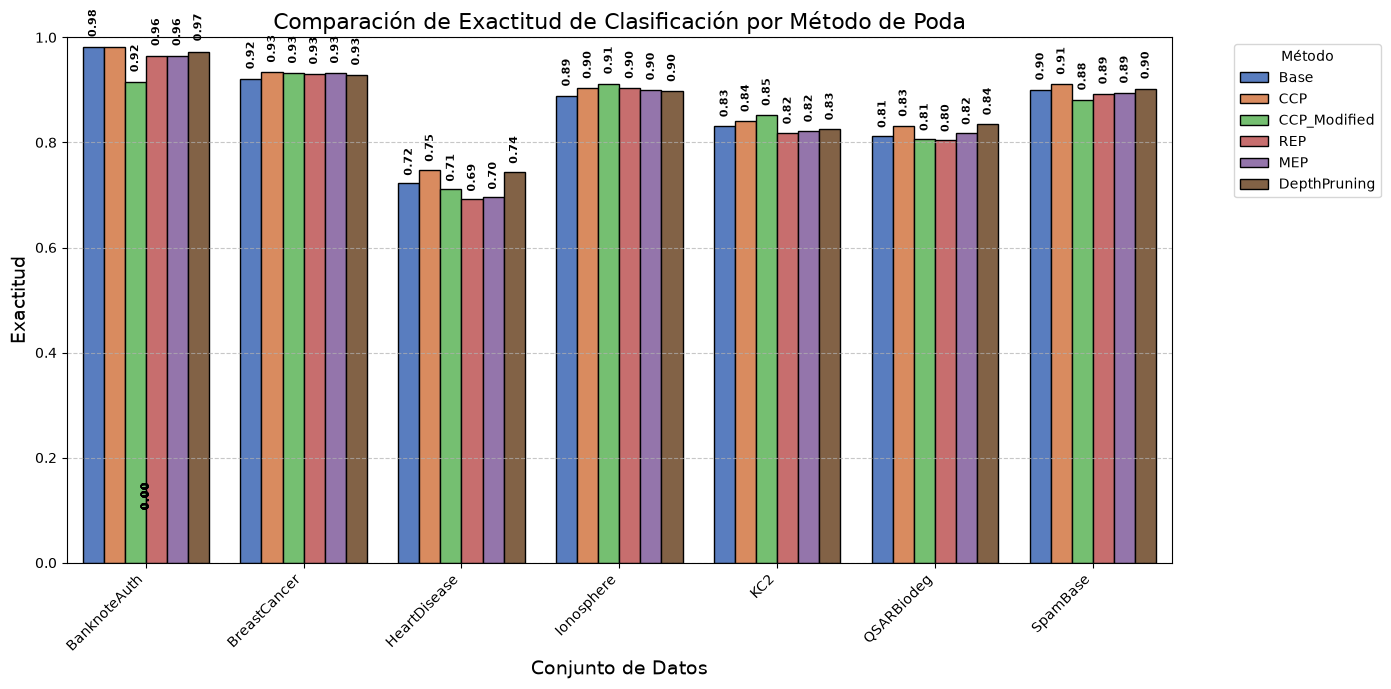

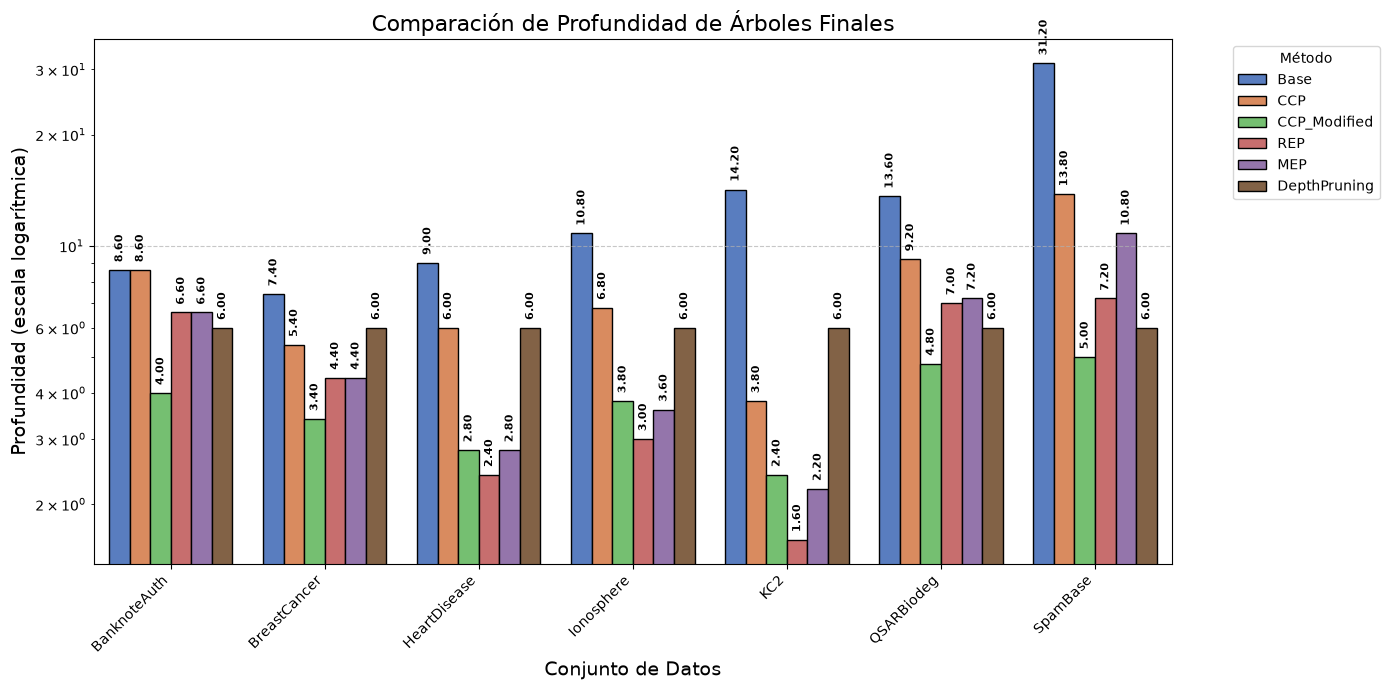

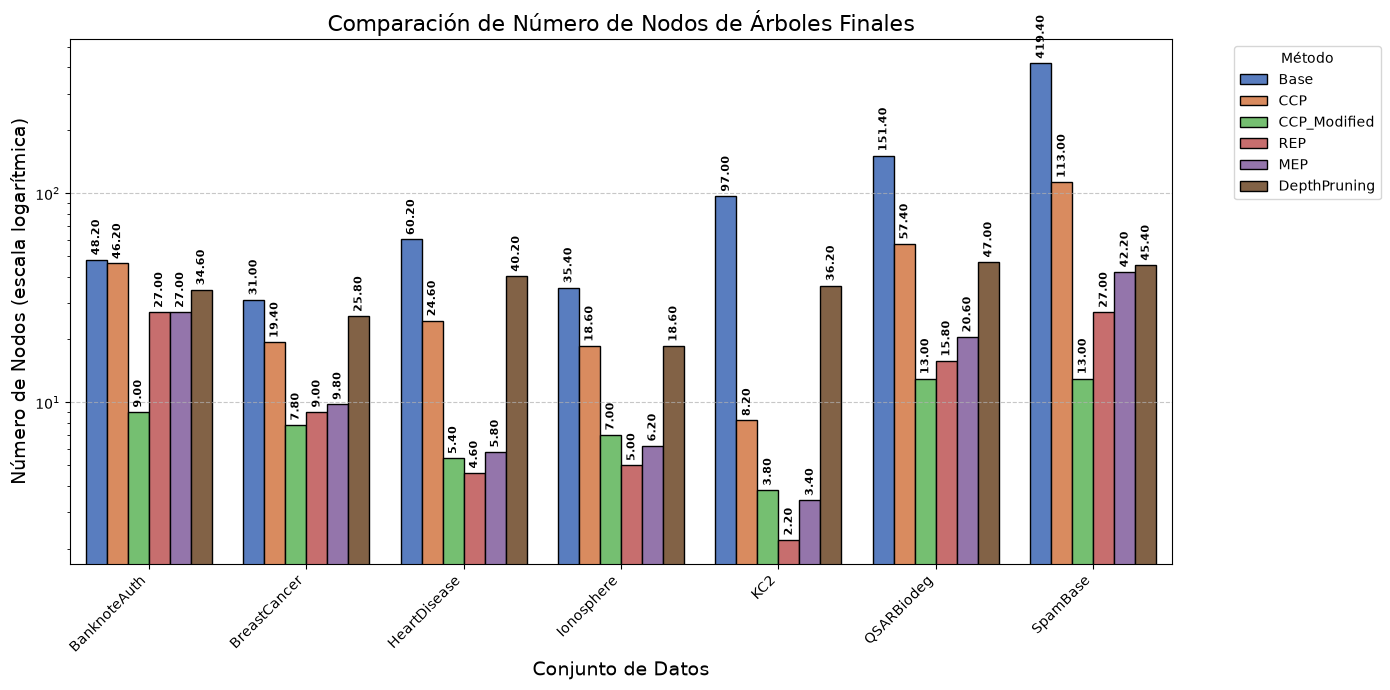

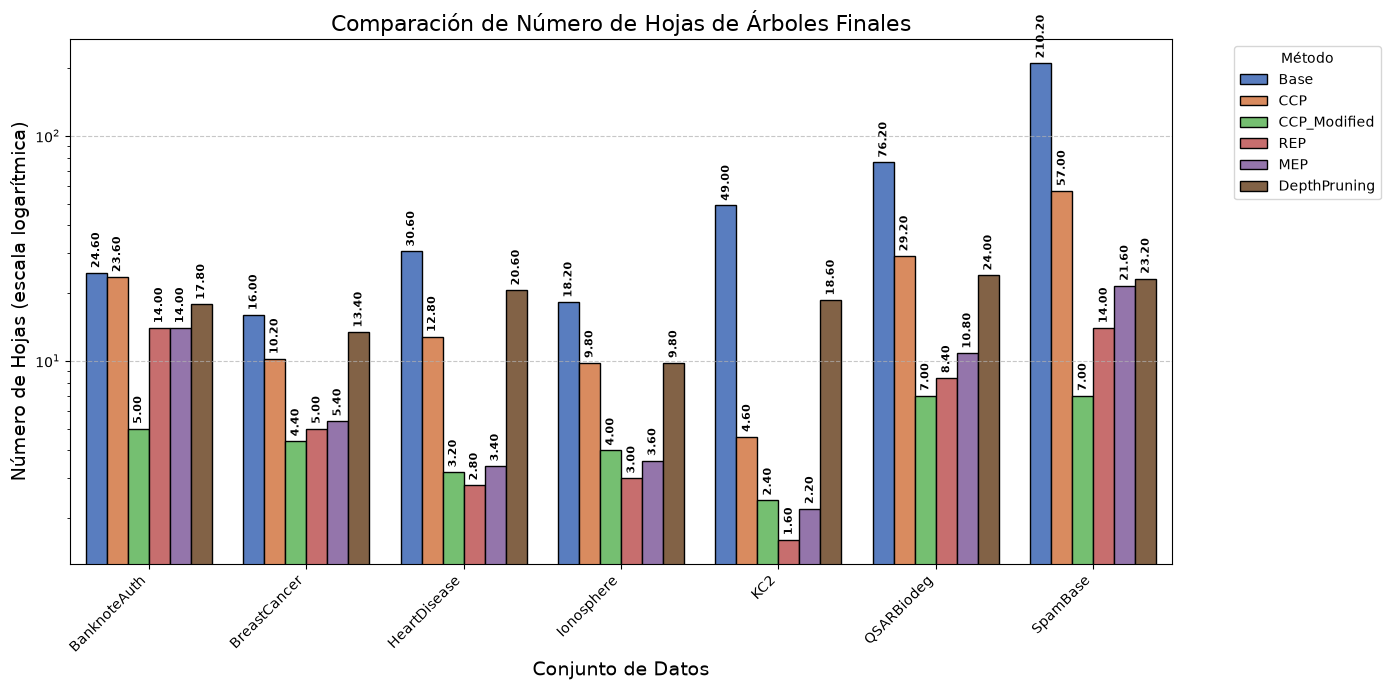

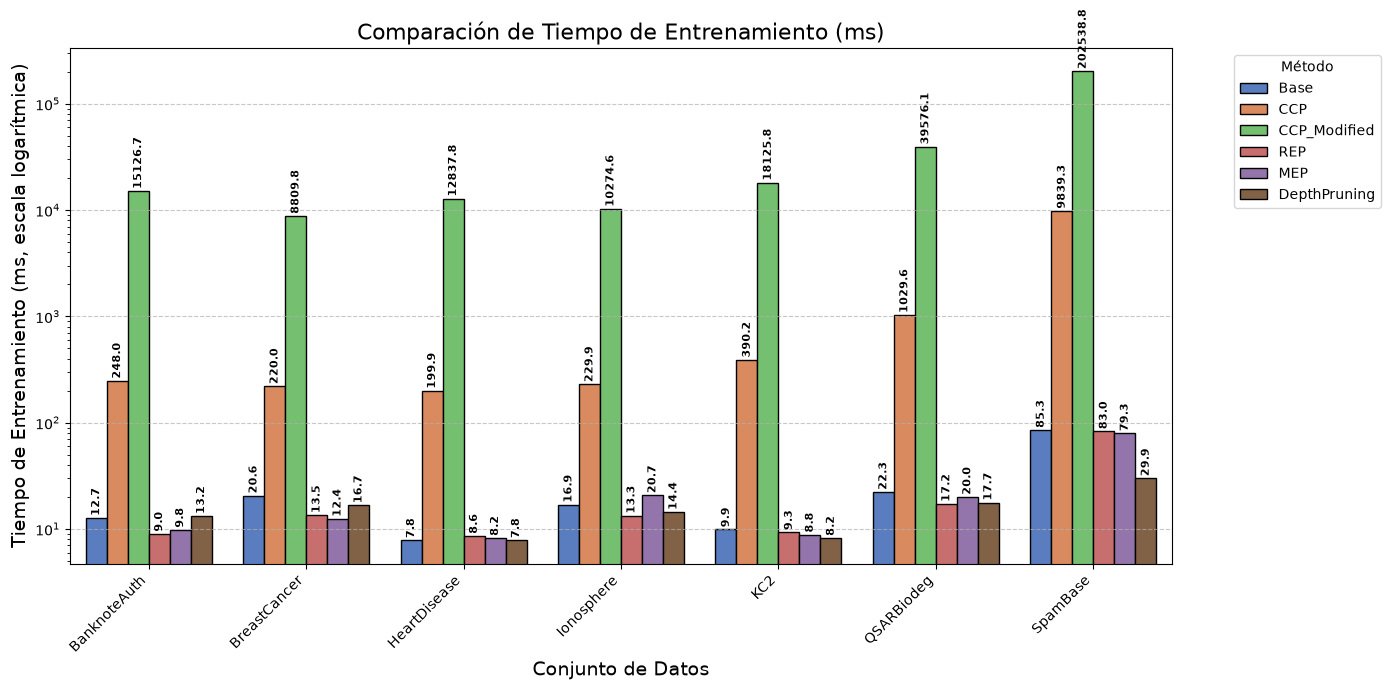

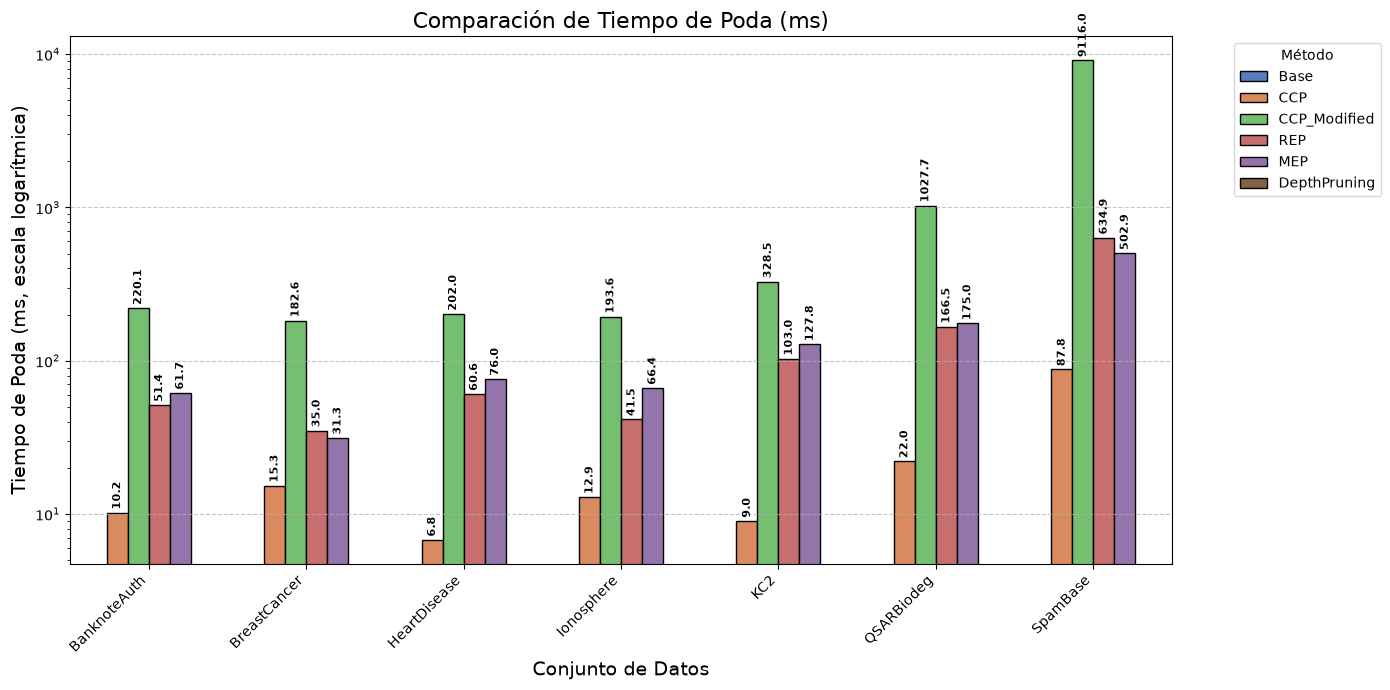

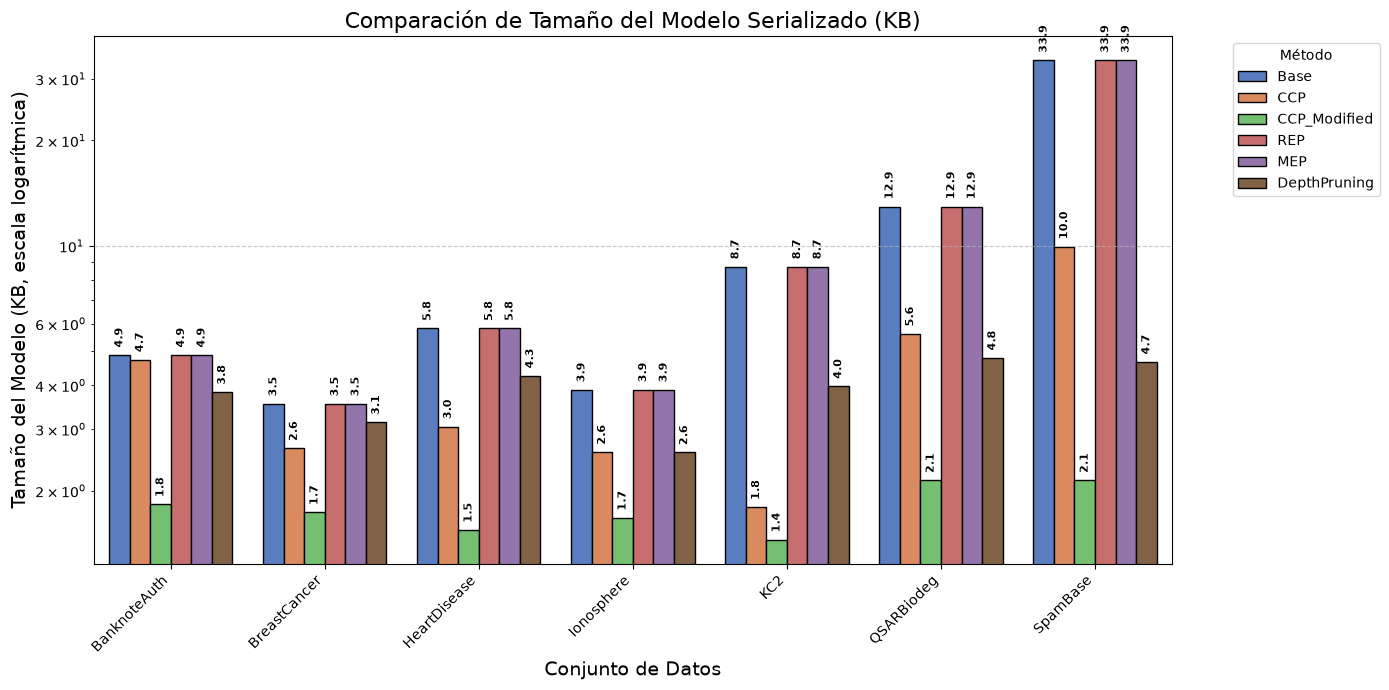

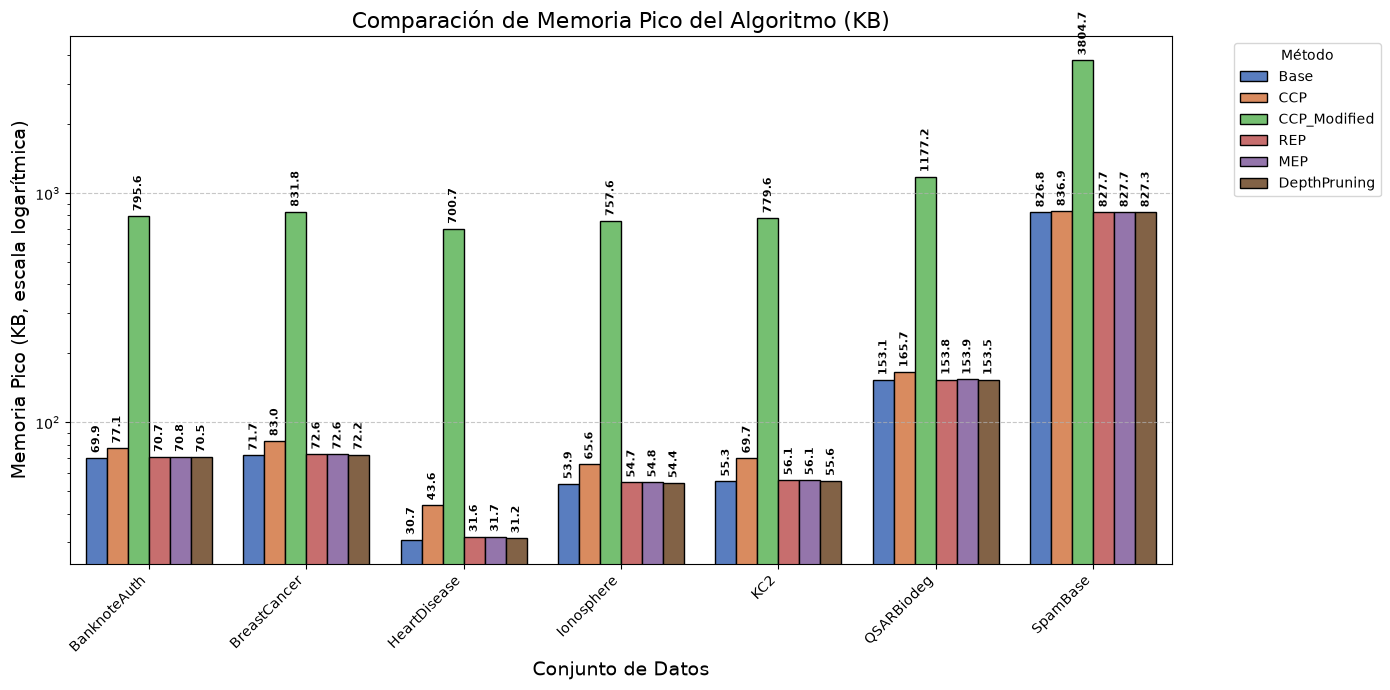

In [14]:
# ======================= RESULTADOS ===========================
results_df = pd.DataFrame(results, columns=[
    "Dataset", "Method", "Accuracy", "F1_Score", "Balanced_Accuracy",
    "Depth", "Nodes", "Leaves", "Inference_Time_ms", "Inference_Time_Std_ms", "n_Features",
    "Train_Time_ms", "Prune_Time_ms", "Memory_KB", "Peak_Memory_KB"
])
print(results_df)

# ========== RESULTADOS ADICIONALES ==========
metrics_df = results_df[["Dataset", "Method", "Accuracy", "F1_Score", "Balanced_Accuracy", "Inference_Time_ms", "Inference_Time_Std_ms", "n_Features", "Train_Time_ms", "Prune_Time_ms", "Memory_KB", "Peak_Memory_KB"]]
accuracy_df = results_df[["Dataset", "Method", "Accuracy"]].rename(columns={"Accuracy": "Test Accuracy"})
details_df = results_df[["Dataset", "Method", "Depth", "Nodes", "Leaves"]]

print("\nMetricas de Prueba por Método:")
print(metrics_df.pivot(index="Dataset", columns="Method"))

print("\nDetalles de Árboles:")
print(details_df)

#========================== ANOVA ===================================

anova_result_acc = f_oneway(*[group['Accuracy'].values for name, group in metrics_df.groupby('Method')])
anova_result_f1 = f_oneway(*[group['F1_Score'].values for name, group in metrics_df.groupby('Method')])
anova_result_bal = f_oneway(*[group['Balanced_Accuracy'].values for name, group in metrics_df.groupby('Method')])

anova_result_leav = f_oneway(*[group['Depth'].values for name, group in details_df.groupby('Method')])
anova_result_depth = f_oneway(*[group['Nodes'].values for name, group in details_df.groupby('Method')])
anova_result_nodes = f_oneway(*[group['Leaves'].values for name, group in details_df.groupby('Method')])

anova_featu_nodes = f_oneway(*[group['n_Features'].values for name, group in metrics_df.groupby('Method')])
print(anova_featu_nodes)

# ========================== CSV FINAL UNIFICADO CON Δacc ==========================

# Obtener accuracy base por dataset
base_accuracies = results_df[results_df["Method"] == "Base"][["Dataset", "Accuracy"]].set_index("Dataset")

# Añadir columna Δacc
results_df["△acc"] = results_df.apply(
    lambda row: row["Accuracy"] - base_accuracies.loc[row["Dataset"], "Accuracy"]
    if row["Method"] != "Base" else 0.0,
    axis=1
)

# Reordenar y renombrar columnas
final_df = results_df[["Dataset", "Method", "Accuracy", "△acc", "F1_Score", "Balanced_Accuracy", "Leaves", "Nodes", "Depth", "Inference_Time_ms", "Inference_Time_Std_ms", "n_Features", "Train_Time_ms", "Prune_Time_ms", "Memory_KB", "Peak_Memory_KB"]]

# Guardar CSV final
final_df.to_csv("FINAL_RESULTADOS.csv", index=False)

# Mostrar resumen final
print("\nCSV Final Consolidado:")
print(final_df)


# Descargar en Colab si aplica
try:
    from google.colab import files
    files.download("FINAL_RESULTADOS.csv")
except:
    print("Descarga automática no disponible (no estás en Colab).")


#==============GRAFICAS INTERPRETABLES==================


# Función para anotar las barras
def annotate_bars(ax, fmt="{:.2f}"):
    """Añade etiquetas numéricas encima de cada barra, separadas adecuadamente."""
    for p in ax.patches:
        height = p.get_height()
        offset = height * 0.020 if height > 0 else 0.1
        ax.annotate(fmt.format(height),
                    (p.get_x() + p.get_width() / 2., height + offset),
                    ha='center', va='bottom',
                    fontsize=8, fontweight='bold', color='black', rotation=90)

# === Gráfica 1: Exactitud por Método ===
plt.figure(figsize=(14, 7))
ax = sns.barplot(data=accuracy_df, x="Dataset", y="Test Accuracy", hue="Method", palette="muted", edgecolor="black")
plt.title("Comparación de Exactitud de Clasificación por Método de Poda", fontsize=16)
plt.ylabel("Exactitud", fontsize=14)
plt.xlabel("Conjunto de Datos", fontsize=14)
plt.xticks(rotation=45, ha="right")
plt.ylim(0, 1)
plt.grid(axis="y", linestyle='--', alpha=0.7)
plt.legend(title="Método", bbox_to_anchor=(1.05, 1), loc='upper left')
annotate_bars(ax, fmt="{:.2f}")
plt.tight_layout()
plt.show()

#CARACTERÍSTICAS

# Función para anotar las barras correctamente, incluso las de valor 0
def annotate_bars(ax, fmt="{:.2f}"):
    """Añade etiquetas numéricas encima de cada barra, manejando valores cero correctamente."""
    for p in ax.patches:
        height = p.get_height()
        if height == 0:
            ax.annotate("0",
                        (p.get_x() + p.get_width() / 2., 0.2),
                        ha='center', va='bottom',
                        fontsize=8, fontweight='bold', color='black', rotation=90)
        else:
            offset = height * 0.05
            ax.annotate(fmt.format(height),
                        (p.get_x() + p.get_width() / 2., height + offset),
                        ha='center', va='bottom',
                        fontsize=8, fontweight='bold', color='black', rotation=90)

# === Gráfica 2: Profundidad de Árboles (con escala logarítmica) ===
plt.figure(figsize=(14, 7))
ax = sns.barplot(data=details_df, x="Dataset", y="Depth", hue="Method", palette="muted", edgecolor="black")
plt.yscale('log')
plt.title("Comparación de Profundidad de Árboles Finales", fontsize=16)
plt.ylabel("Profundidad (escala logarítmica)", fontsize=14)
plt.xlabel("Conjunto de Datos", fontsize=14)
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", linestyle='--', alpha=0.7)
plt.legend(title="Método", bbox_to_anchor=(1.05, 1), loc='upper left')
annotate_bars(ax, fmt="{:.2f}")
plt.tight_layout()
plt.show()

# === Gráfica 3: Cantidad de Nodos (con escala logarítmica) ===
plt.figure(figsize=(14, 7))
ax = sns.barplot(data=details_df, x="Dataset", y="Nodes", hue="Method", palette="muted", edgecolor="black")
plt.yscale('log')
plt.title("Comparación de Número de Nodos de Árboles Finales", fontsize=16)
plt.ylabel("Número de Nodos (escala logarítmica)", fontsize=14)
plt.xlabel("Conjunto de Datos", fontsize=14)
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", linestyle='--', alpha=0.7)
plt.legend(title="Método", bbox_to_anchor=(1.05, 1), loc='upper left')
annotate_bars(ax, fmt="{:.2f}")
plt.tight_layout()
plt.show()

# === Gráfica 4: Cantidad de Hojas (con escala logarítmica) ===
plt.figure(figsize=(14, 7))
ax = sns.barplot(data=details_df, x="Dataset", y="Leaves", hue="Method", palette="muted", edgecolor="black")
plt.yscale('log')
plt.title("Comparación de Número de Hojas de Árboles Finales", fontsize=16)
plt.ylabel("Número de Hojas (escala logarítmica)", fontsize=14)
plt.xlabel("Conjunto de Datos", fontsize=14)
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", linestyle='--', alpha=0.7)
plt.legend(title="Método", bbox_to_anchor=(1.05, 1), loc='upper left')
annotate_bars(ax, fmt="{:.2f}")
plt.tight_layout()
plt.show()

# === Gráfica 5: Tiempo de Entrenamiento (escala log) ===
train_time_df = results_df[["Dataset", "Method", "Train_Time_ms"]]
plt.figure(figsize=(14, 7))
ax = sns.barplot(data=train_time_df, x="Dataset", y="Train_Time_ms", hue="Method", palette="muted", edgecolor="black")
plt.yscale('log')
plt.title("Comparación de Tiempo de Entrenamiento (ms)", fontsize=16)
plt.ylabel("Tiempo de Entrenamiento (ms, escala logarítmica)", fontsize=14)
plt.xlabel("Conjunto de Datos", fontsize=14)
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", linestyle='--', alpha=0.7)
plt.legend(title="Método", bbox_to_anchor=(1.05, 1), loc='upper left')
annotate_bars(ax, fmt="{:.1f}")
plt.tight_layout()
plt.show()

# === Gráfica 6: Tiempo de Poda (escala log) ===
prune_time_df = results_df[["Dataset", "Method", "Prune_Time_ms"]]
plt.figure(figsize=(14, 7))
ax = sns.barplot(data=prune_time_df, x="Dataset", y="Prune_Time_ms", hue="Method", palette="muted", edgecolor="black")
plt.yscale('log')
plt.title("Comparación de Tiempo de Poda (ms)", fontsize=16)
plt.ylabel("Tiempo de Poda (ms, escala logarítmica)", fontsize=14)
plt.xlabel("Conjunto de Datos", fontsize=14)
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", linestyle='--', alpha=0.7)
plt.legend(title="Método", bbox_to_anchor=(1.05, 1), loc='upper left')
annotate_bars(ax, fmt="{:.1f}")
plt.tight_layout()
plt.show()

# === Gráfica 7: Memoria del Modelo Serializado (escala log) ===
memory_df = results_df[["Dataset", "Method", "Memory_KB"]]
plt.figure(figsize=(14, 7))
ax = sns.barplot(data=memory_df, x="Dataset", y="Memory_KB", hue="Method", palette="muted", edgecolor="black")
plt.yscale('log')
plt.title("Comparación de Tamaño del Modelo Serializado (KB)", fontsize=16)
plt.ylabel("Tamaño del Modelo (KB, escala logarítmica)", fontsize=14)
plt.xlabel("Conjunto de Datos", fontsize=14)
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", linestyle='--', alpha=0.7)
plt.legend(title="Método", bbox_to_anchor=(1.05, 1), loc='upper left')
annotate_bars(ax, fmt="{:.1f}")
plt.tight_layout()
plt.show()

# === Gráfica 8: Memoria Pico del Algoritmo (escala log) ===
peak_memory_df = results_df[["Dataset", "Method", "Peak_Memory_KB"]]
plt.figure(figsize=(14, 7))
ax = sns.barplot(data=peak_memory_df, x="Dataset", y="Peak_Memory_KB", hue="Method", palette="muted", edgecolor="black")
plt.yscale('log')
plt.title("Comparación de Memoria Pico del Algoritmo (KB)", fontsize=16)
plt.ylabel("Memoria Pico (KB, escala logarítmica)", fontsize=14)
plt.xlabel("Conjunto de Datos", fontsize=14)
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", linestyle='--', alpha=0.7)
plt.legend(title="Método", bbox_to_anchor=(1.05, 1), loc='upper left')
annotate_bars(ax, fmt="{:.1f}")
plt.tight_layout()
plt.show()


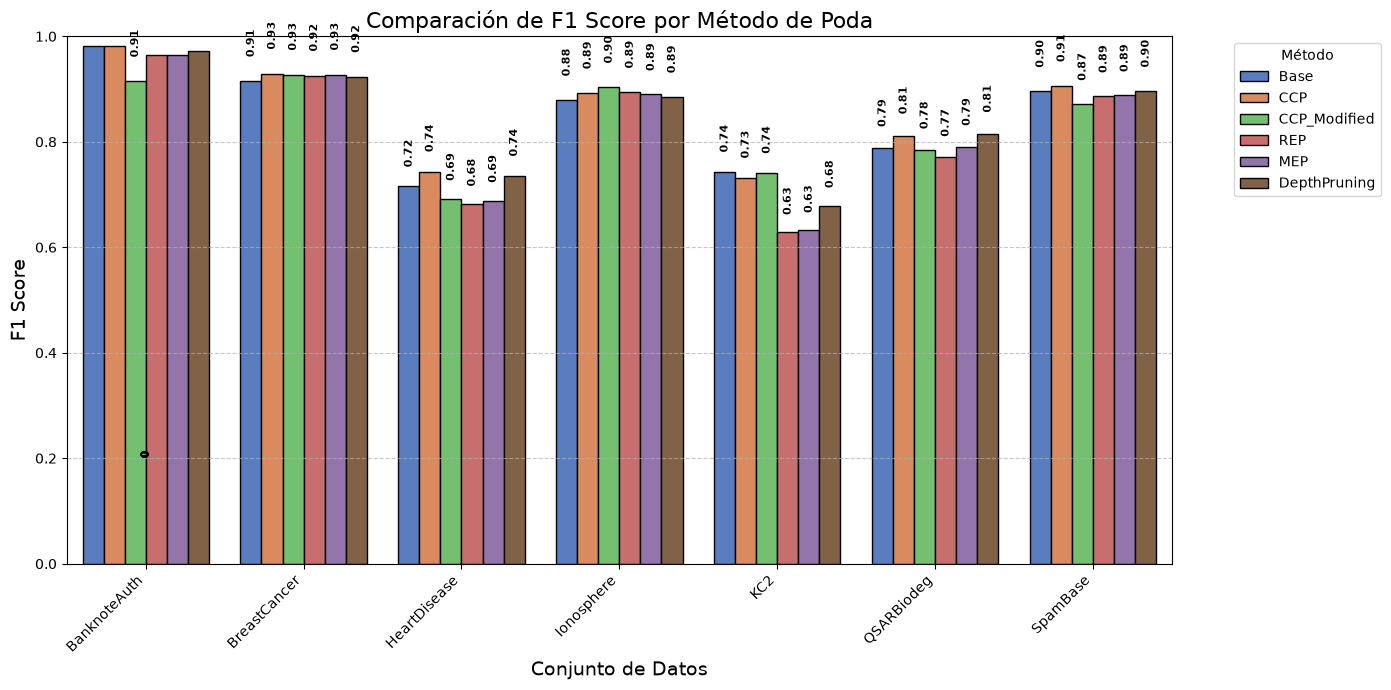

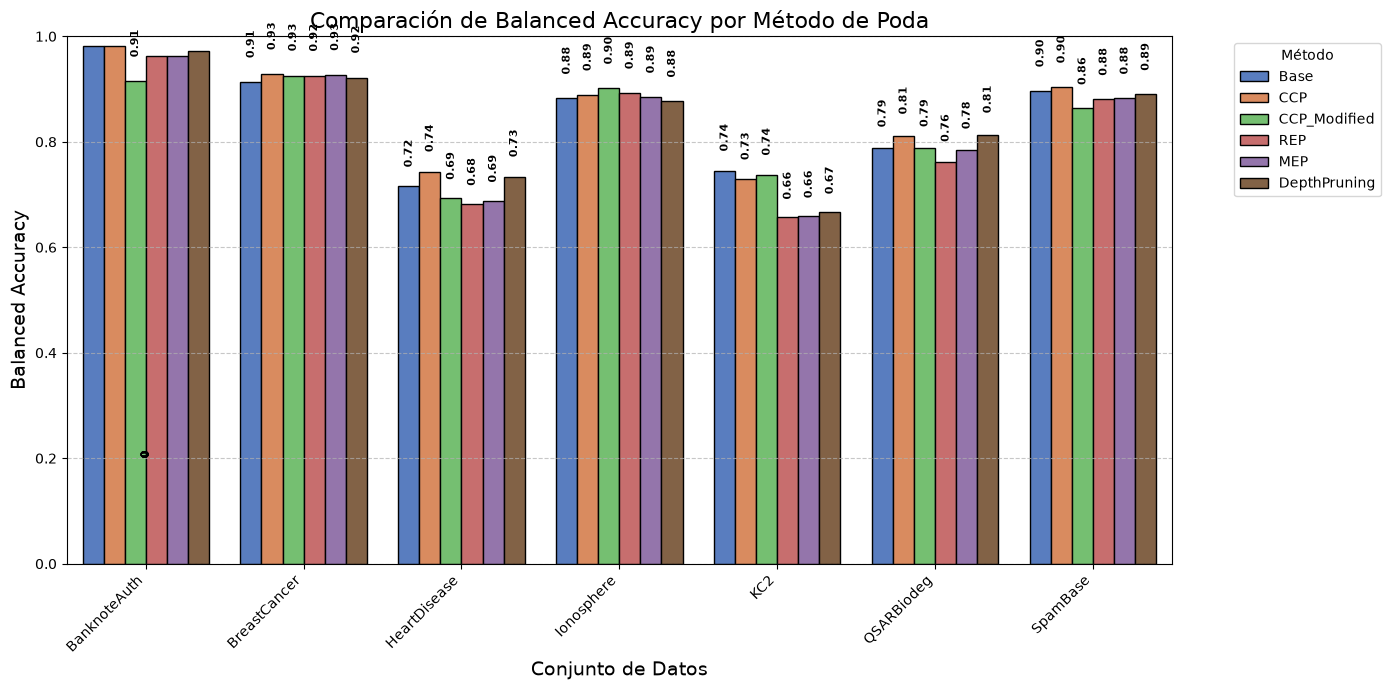

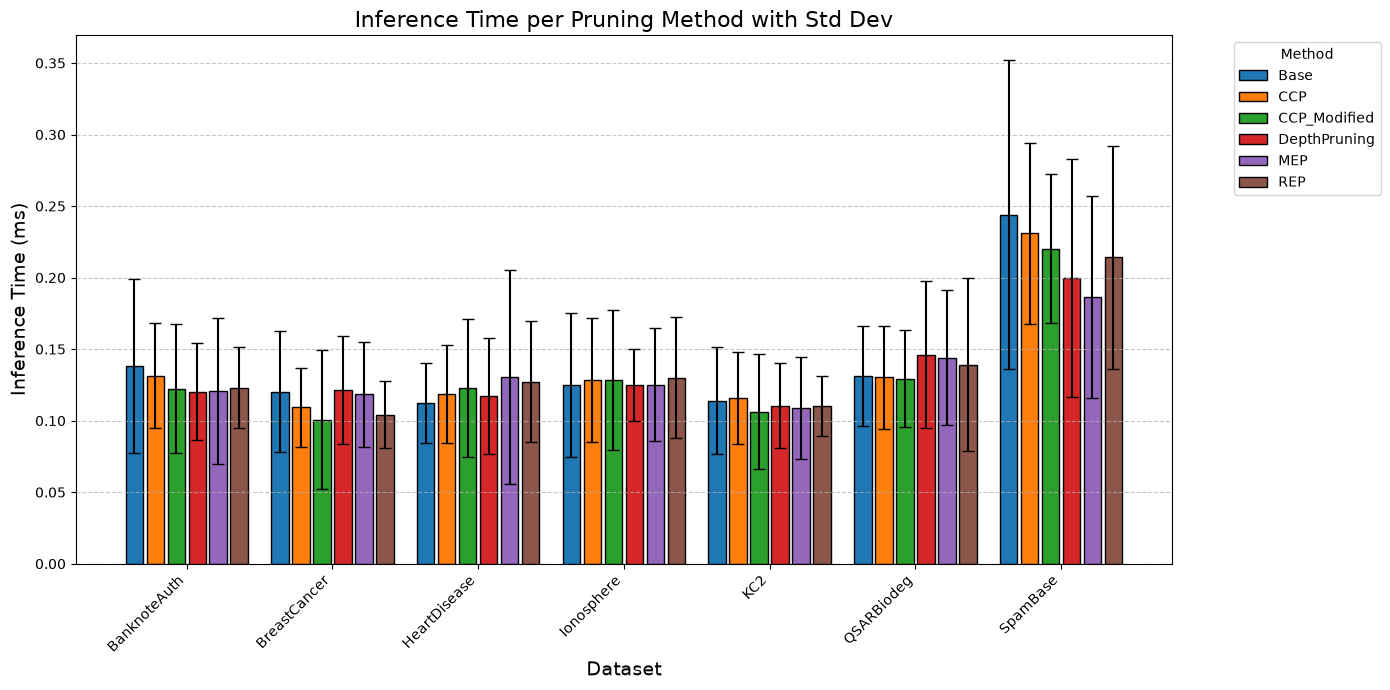

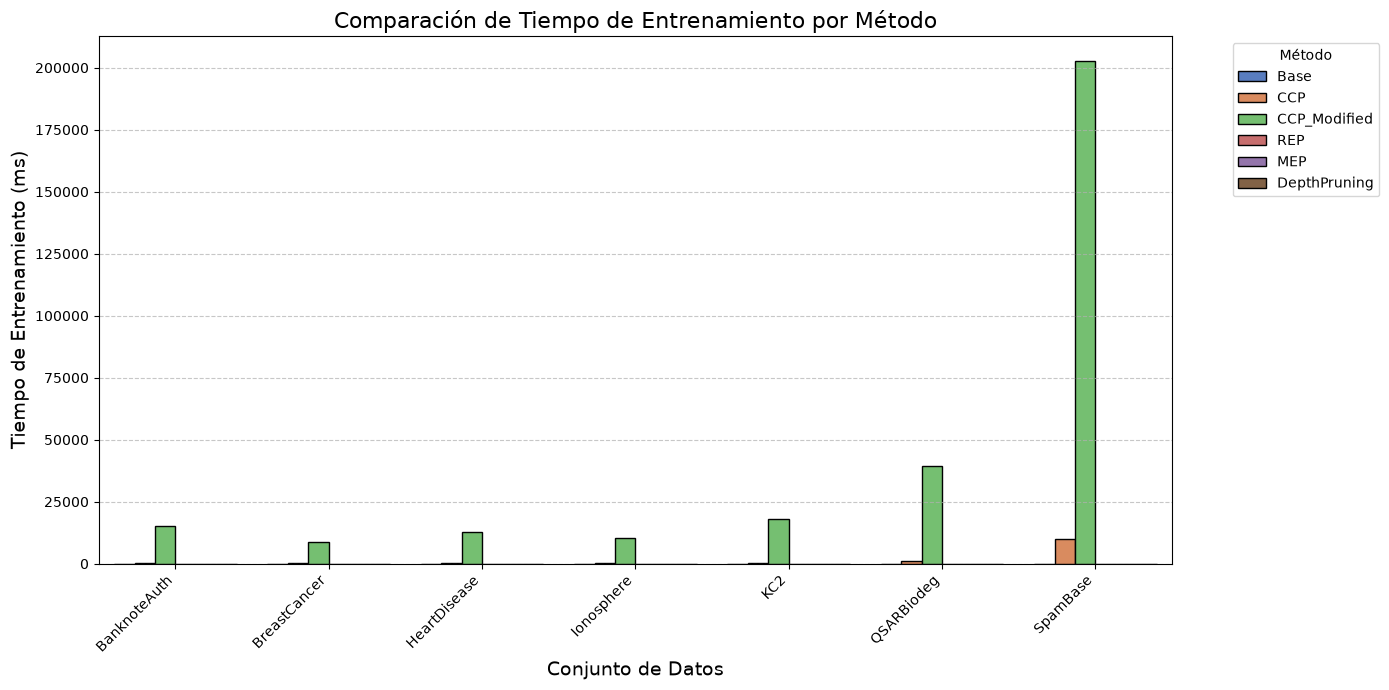

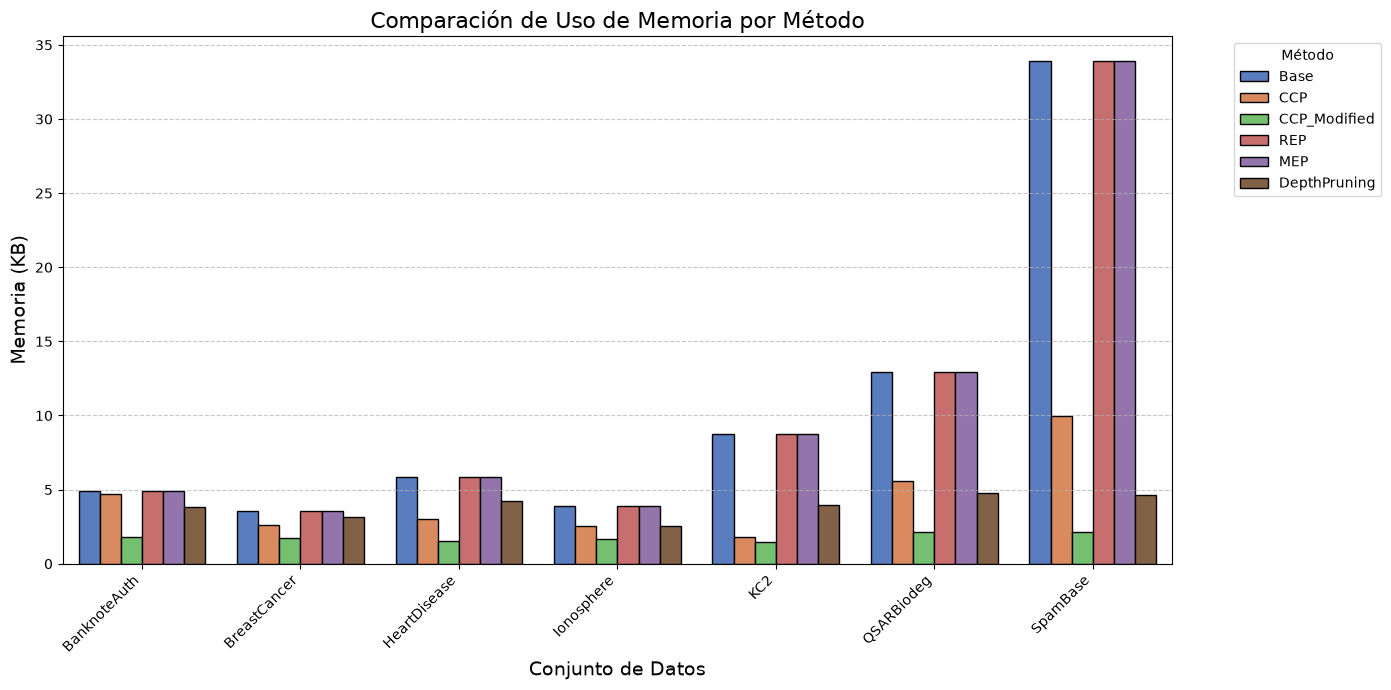

In [15]:
# Gráfica de barras para F1 Score
plt.figure(figsize=(14, 7))
ax = sns.barplot(data=metrics_df, x="Dataset", y="F1_Score", hue="Method", palette="muted", edgecolor="black")
plt.title("Comparación de F1 Score por Método de Poda", fontsize=16)
plt.ylabel("F1 Score", fontsize=14)
plt.xlabel("Conjunto de Datos", fontsize=14)
plt.xticks(rotation=45, ha="right")
plt.ylim(0, 1)
plt.grid(axis="y", linestyle='--', alpha=0.7)
plt.legend(title="Método", bbox_to_anchor=(1.05, 1), loc='upper left')
annotate_bars(ax, fmt="{:.2f}")
plt.tight_layout()
plt.show()

# Gráfica de barras para Balanced Accuracy
plt.figure(figsize=(14, 7))
ax = sns.barplot(data=metrics_df, x="Dataset", y="Balanced_Accuracy", hue="Method", palette="muted", edgecolor="black")
plt.title("Comparación de Balanced Accuracy por Método de Poda", fontsize=16)
plt.ylabel("Balanced Accuracy", fontsize=14)
plt.xlabel("Conjunto de Datos", fontsize=14)
plt.xticks(rotation=45, ha="right")
plt.ylim(0, 1)
plt.grid(axis="y", linestyle='--', alpha=0.7)
plt.legend(title="Método", bbox_to_anchor=(1.05, 1), loc='upper left')
annotate_bars(ax, fmt="{:.2f}")
plt.tight_layout()
plt.show()




# Compute average and std per group
grouped = metrics_df.groupby(["Dataset", "Method"], as_index=False).mean()

# Create the bar plot with error bars
plt.figure(figsize=(14, 7))

# Get unique methods and datasets
methods = grouped["Method"].unique()
datasets = grouped["Dataset"].unique()

# Create position indices for grouped bars
x = np.arange(len(datasets))
width = 0.12  # width of each bar
offsets = np.linspace(-width*len(methods)/2, width*len(methods)/2, len(methods))

for i, method in enumerate(methods):
    subset = grouped[grouped["Method"] == method]
    y = subset["Inference_Time_ms"].values
    yerr = subset["Inference_Time_Std_ms"].values
    plt.bar(x + offsets[i], y, width, label=method, yerr=yerr, capsize=4, edgecolor="black")

plt.xticks(x, datasets, rotation=45, ha="right")
plt.title("Inference Time per Pruning Method with Std Dev", fontsize=16)
plt.xlabel("Dataset", fontsize=14)
plt.ylabel("Inference Time (ms)", fontsize=14)
plt.grid(axis="y", linestyle='--', alpha=0.7)
plt.ylim(bottom=0)
plt.legend(title="Method", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# === Gráfica: Tiempo de Entrenamiento ===
plt.figure(figsize=(14, 7))
ax = sns.barplot(data=metrics_df, x="Dataset", y="Train_Time_ms", hue="Method", palette="muted", edgecolor="black")
plt.title("Comparación de Tiempo de Entrenamiento por Método", fontsize=16)
plt.ylabel("Tiempo de Entrenamiento (ms)", fontsize=14)
plt.xlabel("Conjunto de Datos", fontsize=14)
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", linestyle='--', alpha=0.7)
plt.legend(title="Método", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# === Gráfica: Uso de Memoria ===
plt.figure(figsize=(14, 7))
ax = sns.barplot(data=metrics_df, x="Dataset", y="Memory_KB", hue="Method", palette="muted", edgecolor="black")
plt.title("Comparación de Uso de Memoria por Método", fontsize=16)
plt.ylabel("Memoria (KB)", fontsize=14)
plt.xlabel("Conjunto de Datos", fontsize=14)
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", linestyle='--', alpha=0.7)
plt.legend(title="Método", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


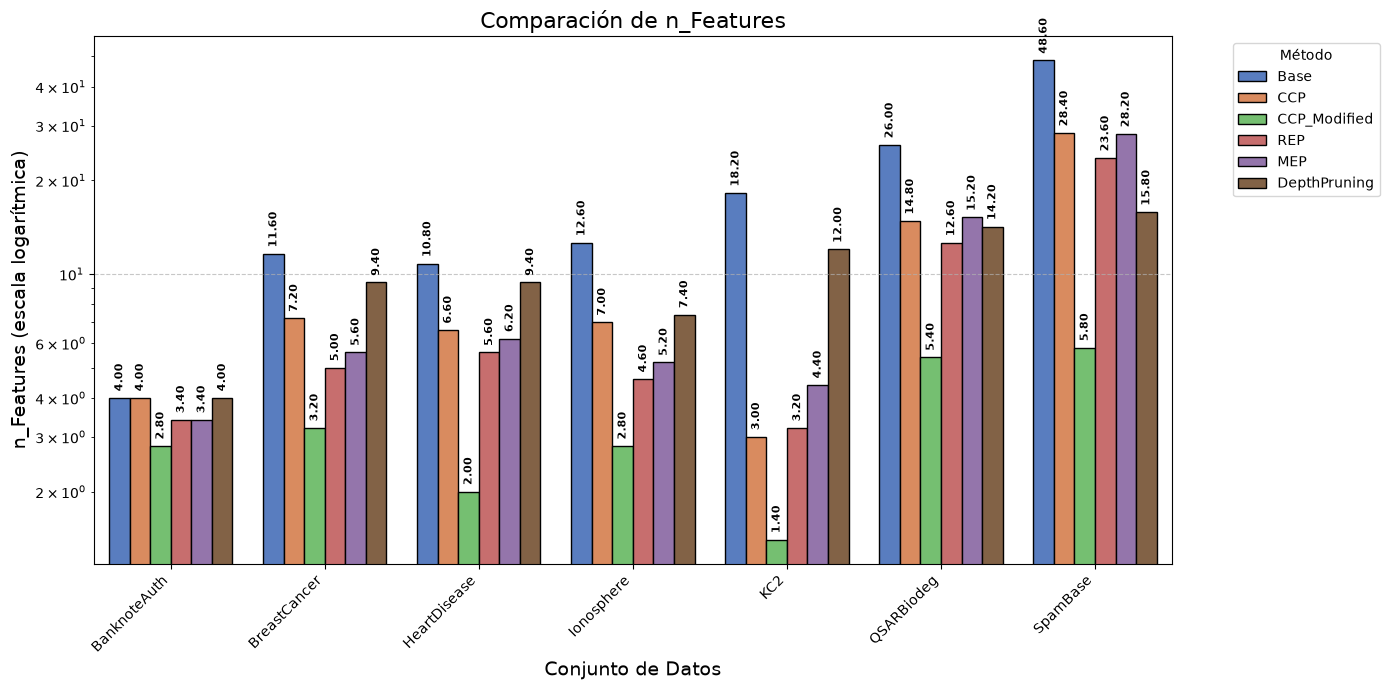

In [16]:
# === Gráfica 5: n_Features ===
plt.figure(figsize=(14, 7))
ax = sns.barplot(data=metrics_df, x="Dataset", y="n_Features", hue="Method", palette="muted", edgecolor="black")
plt.yscale('log')
plt.title("Comparación de n_Features", fontsize=16)
plt.ylabel("n_Features (escala logarítmica)", fontsize=14)
plt.xlabel("Conjunto de Datos", fontsize=14)
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", linestyle='--', alpha=0.7)
plt.legend(title="Método", bbox_to_anchor=(1.05, 1), loc='upper left')
annotate_bars(ax, fmt="{:.2f}")
plt.tight_layout()
plt.show()